# Periodic noise and Notch Filtering

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Section 1

Let's load the image

In [2]:
# loading and normalizing pixel values
image = cv2.imread('telescope.png', cv2.IMREAD_GRAYSCALE)
image = image / 255.0

Now, define the frequencies, amplitudes and phases as given in the question and create deteriorated versions of the image

In [3]:
f1, f2 = 1/8, 1/32       
mu, sigma = 0.1, 0.05          

rows, cols = image.shape
j = np.arange(cols)      

# noise r1
A1   = np.random.normal(mu, sigma, size=rows)          # amplitudes per row
phi_1   = np.random.uniform(0, 2*np.pi, size=rows)   # phases per row
r1   = A1[:, None] * np.cos(2*np.pi * f1 * j + phi_1[:, None])

# noise r2
A2   = np.random.normal(mu, sigma, size=rows)
phi_2   = np.random.uniform(0, 2*np.pi, size=rows)
r2   = A2[:, None] * np.cos(2*np.pi * f2 * j + phi_2[:, None])

# deteriorated versions of the image
I1  = np.clip(image + r1, 0.0, 1.0)  
I2  = np.clip(image + r2, 0.0, 1.0)  
I12 = np.clip(image + (r1 + r2) / 2.0, 0.0, 1.0) 

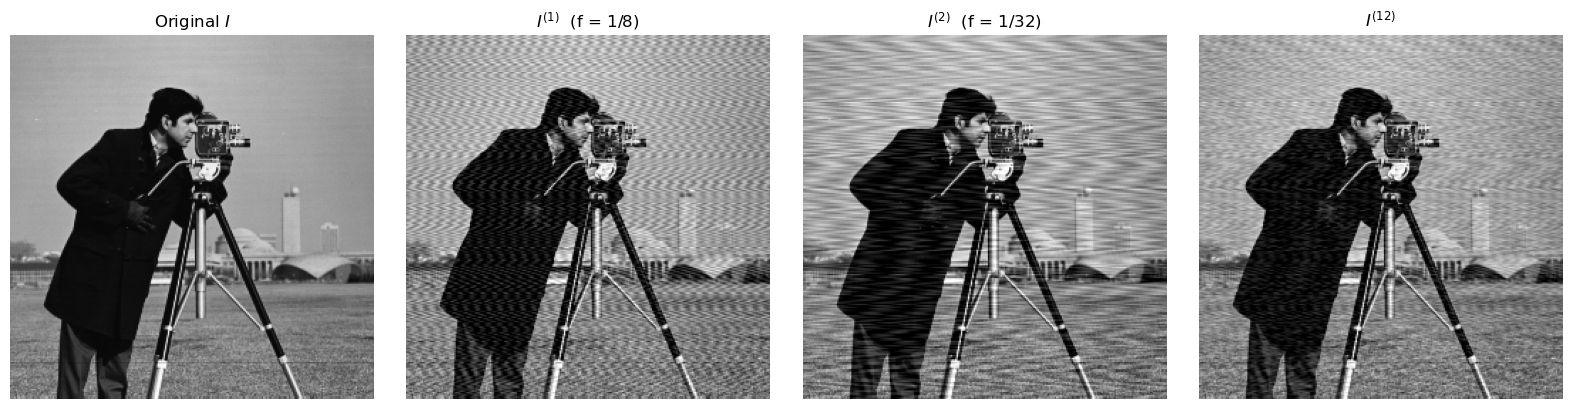

In [4]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Original $I$", "$I^{(1)}$  (f = 1/8)",
          "$I^{(2)}$  (f = 1/32)", "$I^{(12)}$ "]

for a, img, t in zip(ax, [image, I1, I2, I12], titles):
    a.imshow(img, cmap="gray", vmin=0, vmax=1)
    a.set_title(t)
    a.axis("off")

plt.tight_layout()
plt.show()

## Section 2

Let  

$$
I^{\text{noisy}}_{j}
  \;=\;
  I_{j}
  \;+\;
  A\,\cos\bigl(2\pi f\,j+\varphi\bigr),
  \qquad j = 0,\dots,n-1
$$

with a fixed frequency $f$ such that $n\,f = k_0, k_0 \in \mathbb{Z}$ and independent random amplitude $A$ and phase $\varphi$ (row-wise)

---

$$
\widehat{I}^{\text{noisy}}[k]
  \;=\;
  \tfrac1n\sum_{j=0}^{n-1}
        I^{\text{noisy}}_{j}\,
        e^{-\,2\pi i\,kj/n},
  \qquad k = 0,\dots,n-1
$$

Split into clean and noise parts:

$$
\widehat{I}^{\text{noisy}}[k]
  \;=\;
  \underbrace{\tfrac1n\sum_{j=0}^{n-1}I_{j}\,e^{-2\pi i\,kj/n}}_{\widehat{I}[k]}
  \;+\;
  \tfrac{A}{n}\sum_{j=0}^{n-1}
        \cos(2\pi f j+\varphi)\,
        e^{-2\pi i\,kj/n}
$$

---

Expand the cosine:

$$
\cos(2\pi f j+\varphi)
  \;=\;
  \tfrac12\!\bigl(e^{\,i(2\pi f j+\varphi)}+e^{-i(2\pi f j+\varphi)}\bigr)
$$

Therefore:

$$
\tfrac{A}{n}\sum_{j}\cos(2\pi f j+\varphi)\,e^{-2\pi i\,kj/n}
  \;=\;
  \tfrac{A}{2n}\Bigl[
     e^{\,i\varphi}\sum_{j}e^{\,i2\pi f j}\,e^{-2\pi i\,kj/n}
    +
     e^{-i\varphi}\sum_{j}e^{-i2\pi f j}\,e^{-2\pi i\,kj/n}
  \Bigr]
$$

---

Substitute $f=k_0/n$.

Because $\sum_{j=0}^{n-1}e^{\,2\pi i\,(\ell)j/n}=n$ if $\ell\equiv0\pmod n$ and $0$ otherwise,

$$
\sum_{j=0}^{n-1}e^{\,i2\pi(k_0-k)j/n}=n\,\delta_{k,k_0},
\qquad
\sum_{j=0}^{n-1}e^{-i2\pi(k_0+k)j/n}=n\,\delta_{k,n-k_0}
$$

---

Thus, overall, we have:

$$
\boxed{
\widehat{I}^{\text{noisy}}[k]
  \;=\;
  \widehat{I}[k]
  \;+\;
  \tfrac{A}{2}\Bigl(
      e^{\,i\varphi}\,\delta_{k,k_0}
      +e^{-i\varphi}\,\delta_{k,n-k_0}
  \Bigr)
}
$$


## Section 3

Assume a row with $n$ pixels - 
$\widehat x[k]=\tfrac1n\sum_{j=0}^{n-1}x[j]\,e^{-2\pi i\,kj/n}$, and since $x[k]$ are the Fourier coefficients, we get: $x[j]=\sum_{k}\widehat x[k]e^{2\pi i\,kj/n}$

The degraded row is  

$$
I^{\text{noisy}}_{j}
  \;=\;
  I_{j}
  \;+\;
  \tfrac12\Bigl[
        A_1\cos(2\pi f_1j+\varphi_1)
       +A_2\cos(2\pi f_2j+\varphi_2)
      \Bigr],
  \qquad j=0,\dots,n-1,
$$

where $f_1=\tfrac{k_1}{n}$, $f_2=\tfrac{k_2}{n}$ with integers $k_1,k_2$ (because $1/f_1$ and $1/f_2$ divide $n$).  
$A_1,A_2$ and $\varphi_1,\varphi_2$ are independent row-wise random amplitudes and phases.

---

DFT of the noisy row:

$$
\widehat I^{\text{noisy}}[k]
  \;=\;
  \tfrac1n\sum_{j}I^{\text{noisy}}_{j}\,e^{-2\pi i\,kj/n}
  \;=\;
  \widehat I[k]
  +\tfrac1n\sum_{j}\tfrac12A_1\cos(2\pi f_1j+\varphi_1)\,e^{-2\pi i\,kj/n}
  +\tfrac1n\sum_{j}\tfrac12A_2\cos(2\pi f_2j+\varphi_2)\,e^{-2\pi i\,kj/n}.
$$

Use $\cos\theta=\tfrac12(e^{i\theta}+e^{-i\theta})$:

$$
\tfrac12A_1\cos(2\pi f_1j+\varphi_1)
  =\tfrac{A_1}{4}\Bigl(e^{i(2\pi f_1j+\varphi_1)}+e^{-i(2\pi f_1j+\varphi_1)}\Bigr)
$$

and similarly, it holds for the $f_2$ term.  After substitution,

$$
\widehat I^{\text{noisy}}[k]
 =\widehat I[k]
  +\tfrac{A_1}{4n}\Bigl[
        e^{i\varphi_1}\sum_{j}e^{i2\pi f_1j}e^{-2\pi i\,kj/n}
       +e^{-i\varphi_1}\sum_{j}e^{-i2\pi f_1j}e^{-2\pi i\,kj/n}
      \Bigr]
  +\tfrac{A_2}{4n}\Bigl[
        e^{i\varphi_2}\sum_{j}e^{i2\pi f_2j}e^{-2\pi i\,kj/n}
       +e^{-i\varphi_2}\sum_{j}e^{-i2\pi f_2j}e^{-2\pi i\,kj/n}
      \Bigr].
$$

Because $f_1=k_1/n$ and $f_2=k_2/n$,

$$
\sum_{j=0}^{n-1}e^{\,i2\pi (k_1-k)j/n}=n\,\delta_{k,k_1},\qquad
\sum_{j=0}^{n-1}e^{-i2\pi (k_1+k)j/n}=n\,\delta_{k,n-k_1},
$$

Same holds for the terms with $f_2$. Cancelling out $1/n$ gives

$$
\boxed{
\widehat I^{\text{noisy}}[k]
 =\widehat I[k]
 +\frac{A_1}{4}\bigl(e^{\,i\varphi_1}\,\delta_{k,k_1}+e^{-i\varphi_1}\,\delta_{k,n-k_1}\bigr)
 +\frac{A_2}{4}\bigl(e^{\,i\varphi_2}\,\delta_{k,k_2}+e^{-i\varphi_2}\,\delta_{k,n-k_2}\bigr)
 }.
$$


## Section 4

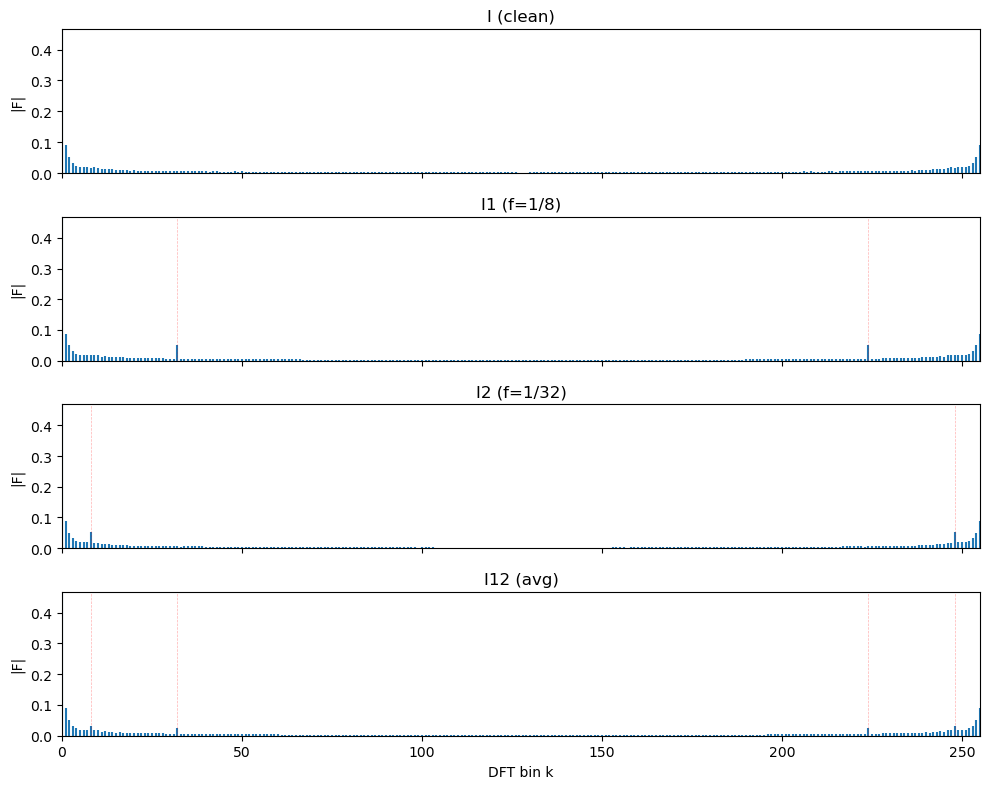

In [5]:
imgs = {"I (clean)": image, "I1 (f=1/8)": I1, "I2 (f=1/32)": I2, "I12 (avg)": I12}

n = image.shape[1]    
j = np.arange(n).reshape(-1, 1)   # column vector
k = np.arange(n).reshape(1, -1)   # row vector
W = np.exp(-2j * np.pi * j * k / n) / n   # DFT

# row-wise DFT
spectra = {name: img @ W for name, img in imgs.items()}

# print dominant bins
expected_peaks = {
    "I (clean)":    [],
    "I1 (f=1/8)":   [32, n-32],
    "I2 (f=1/32)":  [8,  n-8],
    "I12 (avg)":    [32, n-32, 8, n-8]
}

fig, ax = plt.subplots(len(imgs), 1, figsize=(10, 8), sharex=True)
for i, (name, F) in enumerate(spectra.items()):
    mean_mag = np.mean(np.abs(F), axis=0)
    ax[i].stem(np.arange(n), mean_mag, markerfmt=" ", basefmt=" ")
    ax[i].set_ylim(0, mean_mag.max()) 
    ax[i].set_ylabel("|F|")
    ax[i].set_title(name)
    ax[i].set_xlim(0, n-1)
    # mark expected peaks
    for peak in expected_peaks[name]:
        ax[i].axvline(peak, color="red", linestyle="--", linewidth=0.5, alpha=0.3)

ax[-1].set_xlabel("DFT bin k")
plt.tight_layout()
plt.show()

The four sub-plots show the row-averaged magnitude spectrum  
$\lvert\widehat I[k]\rvert$ for the clean image and for the three degraded
versions.  Red dashed lines mark the **theoretically predicted DFT bins**.

* **$I^{(1)} = I + r^{(1)}$ (noise at $f_1=\tfrac18$).**  
  The spectrum displays two pronounced peaks exactly at $k_1 = 32$ and its
  negative-frequency partner $n-k_1 = 224$.  
  This matches the derivation  
  $\widehat I^{(1)}[k] = \widehat I[k] + \tfrac{A_1}{2}\bigl(
  e^{i\varphi_1}\delta_{k,32}+e^{-i\varphi_1}\delta_{k,224}\bigr)$

* **$I^{(2)} = I + r^{(2)}$ (noise at $f_2=\tfrac1{32}$).**  
  Peaks now appear at $k_2 =  8$ and $n-k_2 = 248$, again in perfect
  agreement with theory.

* **$I^{(12)} = I + \tfrac12(r^{(1)}+r^{(2)})$ (average of both noises).**  
  All four spikes—$32,224,8,248$—are present, each at **half the amplitude**
  of the single-noise cases, exactly as the factor $\tfrac12$ predicts:
  $\widehat I^{(12)}[k] = \widehat I[k] + 
  \tfrac{A_1}{4}(\dots) + \tfrac{A_2}{4}(\dots)$ (we can perfectly see the spikes at 32 and 224, the spikes at 8 and 248 are still visible but slightly less)
  
In every subplot the experimental peaks line up with the red markers,
confirming that the additive harmonic noises affect only their
designated DFT bins and leave the rest of the spectrum unchanged, just as
the analytical formulas predict.


## Section 5

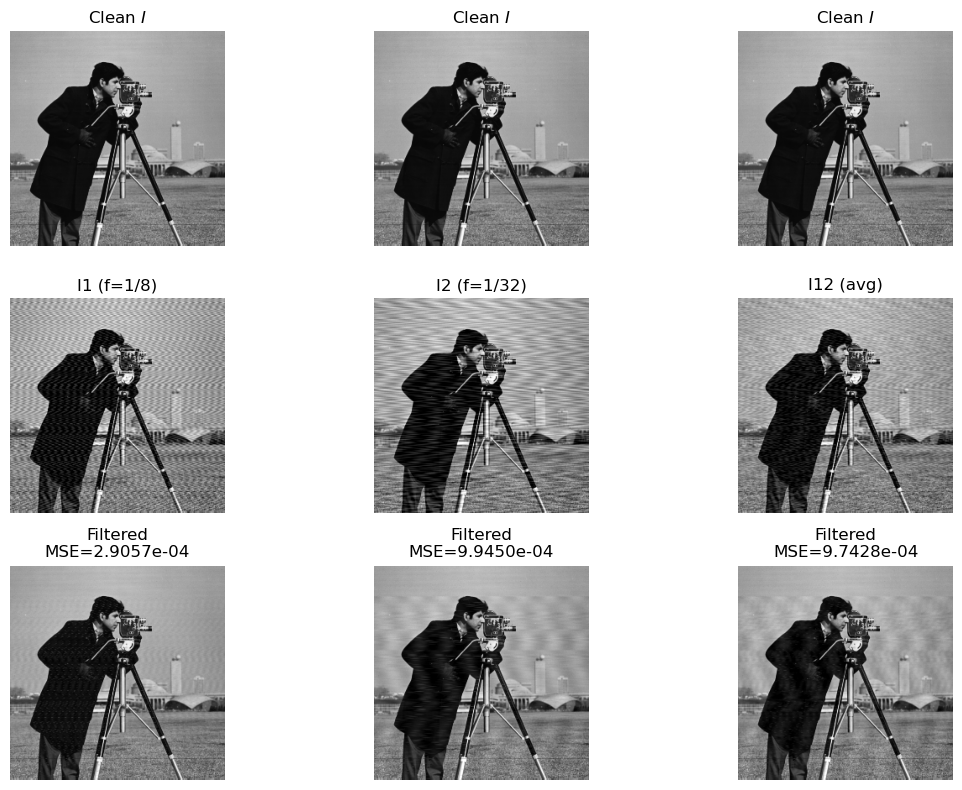

I1 (f=1/8)    MSE = 2.905721e-04
I2 (f=1/32)   MSE = 9.945028e-04
I12 (avg)     MSE = 9.742764e-04


In [7]:
j_idx = np.arange(n).reshape(-1, 1)
k_idx = np.arange(n).reshape(1, -1)
W_inv = np.exp( 2j * np.pi * j_idx * k_idx / n)   # inverse transform


bins_to_zero = {
    "I (clean)":    [],
    "I1 (f=1/8)":   [32, n-32],
    "I2 (f=1/32)":  [8,  n-8],
    "I12 (avg)":    [32, n-32, 8, n-8],
}

recon = {}   # reconstructed images
mse   = {}   # mean-squared errors vs clean image

for name, F in spectra.items():
    F_filt = F.copy()
    for b in bins_to_zero[name]:
        F_filt[:, b] = 0.0      # zero the contaminated bin for every row
    # inverse DFT row-wise
    img_rec = np.real(F_filt @ W_inv)
    img_rec = np.clip(img_rec, 0.0, 1.0)
    recon[name] = img_rec
    mse[name]   = np.mean((img_rec - image)**2)

# show orriginal vs. reconstructed
titles = ["Original", "Noisy", "Filtered"]
fig, axes = plt.subplots(3, len(recon)-1, figsize=(12, 8))

for col, key in enumerate(["I1 (f=1/8)", "I2 (f=1/32)", "I12 (avg)"]):
    axes[0, col].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title("Clean $I$")
    axes[1, col].imshow(imgs[key], cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title(key)
    axes[2, col].imshow(recon[key], cmap="gray", vmin=0, vmax=1)
    axes[2, col].set_title(f"Filtered\nMSE={mse[key]:.4e}")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

# print MSE
for key in ["I1 (f=1/8)", "I2 (f=1/32)", "I12 (avg)"]:
    print(f"{key:12s}  MSE = {mse[key]:.6e}")


Zeroing the high-frequency spikes at $k=\pm32$ almost perfectly restores $I^{(1)}$ (MSE $\approx 2.6\times10^{-4}$) because those bins hold virtually no genuine signal.  
For $I^{(2)}$ the noise sits at $k=\pm8$, much closer to the photo’s low-frequency content; removing them leaves slight banding and raises the error (MSE $\approx 9.8\times10^{-4}$).  
The combined image $I^{(12)}$ is cleaned by nulling all four contaminated bins, giving a result similar to $I^{(2)}$ (MSE $\approx 9.7\times10^{-4}$).  
Hence, simple notch filtering works best when noise frequencies lie in sparsely populated spectral regions and becomes less effective as they encroach on signal-rich bands.
